# 5. Autoencoder

This notebook implements two autoencoder regimes on the **IEEE-CIS primary dataset**:

1. **Semi-supervised Autoencoder**: train only on legitimate transactions (`isFraud = 0`), then score all test rows by reconstruction error.
2. **Supervised Autoencoder**: train on the full training set, using fraud-weighted reconstruction loss so anomalies matter more during training.

The notebook follows the same processed data pipeline as Phase 03/04:
- chronological split already saved in `data/processed/ieee_train.parquet` and `ieee_test.parquet`
- raw encoded features + engineered features stored in `dataset_info.json`
- no leakage: scaling is fit on training data only


In [1]:
# PREPARATION
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, classification_report, f1_score
)

sns.set_style('whitegrid')
torch.manual_seed(42)
np.random.seed(42)

ROOT = Path().resolve().parent
with open(ROOT / 'data/processed/dataset_info.json', 'r') as f:
    info = json.load(f)

train_ieee = pd.read_parquet(ROOT / 'data/processed/ieee_train.parquet')
test_ieee  = pd.read_parquet(ROOT / 'data/processed/ieee_test.parquet')

raw_ieee = info['ieee']['raw_features']
eng_ieee = info['ieee']['engineered_features']
all_ieee = raw_ieee + eng_ieee

y_train = train_ieee['isFraud'].values
y_test  = test_ieee['isFraud'].values

X_train = train_ieee[all_ieee].fillna(-999).copy()
X_test  = test_ieee[all_ieee].fillna(-999).copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")
print(f"Fraud rate (train): {y_train.mean()*100:.3f}%")
print(f"Fraud rate (test):  {y_test.mean()*100:.3f}%")


Train shape: (472432, 64)
Test shape:  (118108, 64)
Fraud rate (train): 3.514%
Fraud rate (test):  3.441%


In [2]:
# MODELING HELPERS
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16, hidden_1=128, hidden_2=64, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


def make_loader(X, y=None, batch_size=1024, shuffle=True):
    x_tensor = torch.tensor(X, dtype=torch.float32)
    if y is None:
        ds = TensorDataset(x_tensor)
    else:
        y_tensor = torch.tensor(y, dtype=torch.float32)
        ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_autoencoder(model, loader, epochs=20, lr=1e-3, weight_mode='uniform'):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss(reduction='none')
    history = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for batch in loader:
            if len(batch) == 1:
                xb = batch[0].to(DEVICE)
                yb = None
            else:
                xb, yb = batch[0].to(DEVICE), batch[1].to(DEVICE)

            optimizer.zero_grad()
            x_hat, _ = model(xb)
            per_feature_loss = criterion(x_hat, xb)
            per_row_loss = per_feature_loss.mean(dim=1)

            if weight_mode == 'fraud_weighted' and yb is not None:
                # Give fraudulent rows higher influence during supervised AE training
                weights = torch.where(yb > 0, torch.tensor(8.0, device=DEVICE), torch.tensor(1.0, device=DEVICE))
                loss = (per_row_loss * weights).mean()
            else:
                loss = per_row_loss.mean()

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        history.append(np.mean(epoch_losses))
        print(f"Epoch {epoch+1:02d}/{epochs} - loss: {history[-1]:.6f}")

    return history


@torch.no_grad()
def reconstruction_error(model, X, batch_size=2048):
    model.eval()
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    errors = []
    latents = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        x_hat, z = model(xb)
        err = ((x_hat - xb) ** 2).mean(dim=1).cpu().numpy()
        errors.append(err)
        latents.append(z.cpu().numpy())
    return np.concatenate(errors), np.concatenate(latents)


def evaluate_scores(y_true, scores, label='model'):
    auprc = average_precision_score(y_true, scores)
    roc = roc_auc_score(y_true, scores)
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_vals = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = np.argmax(f1_vals)
    best_thr = thresholds[best_idx]
    y_pred = (scores >= best_thr).astype(int)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    metrics = {
        'model': label,
        'AUPRC': auprc,
        'ROC_AUC': roc,
        'best_f1_threshold': float(best_thr),
        'best_f1': float(f1),
        'precision_at_best_f1': float(precision[:-1][best_idx]),
        'recall_at_best_f1': float(recall[:-1][best_idx]),
        'confusion_matrix': cm.tolist()
    }
    return metrics, (precision, recall, thresholds, f1_vals)


Device: cpu


In [3]:
# SEMI-SUPERVISED AUTOENCODER
# Train ONLY on normal transactions.
X_train_normal = X_train_scaled[y_train == 0]
print('Semi-supervised training rows:', X_train_normal.shape[0])

semi_loader = make_loader(X_train_normal, batch_size=1024, shuffle=True)
semi_ae = Autoencoder(input_dim=X_train_scaled.shape[1], latent_dim=16)
semi_history = train_autoencoder(semi_ae, semi_loader, epochs=20, lr=1e-3, weight_mode='uniform')

semi_scores_test, semi_latent_test = reconstruction_error(semi_ae, X_test_scaled)
semi_metrics, semi_curve = evaluate_scores(y_test, semi_scores_test, label='AE_SemiSupervised')
print(pd.Series(semi_metrics))


Semi-supervised training rows: 455833
Epoch 01/20 - loss: 0.327252
Epoch 02/20 - loss: 0.136860
Epoch 03/20 - loss: 0.111056
Epoch 04/20 - loss: 0.099349
Epoch 05/20 - loss: 0.092665
Epoch 06/20 - loss: 0.087137
Epoch 07/20 - loss: 0.083080
Epoch 08/20 - loss: 0.079308
Epoch 09/20 - loss: 0.076667
Epoch 10/20 - loss: 0.073637
Epoch 11/20 - loss: 0.071141
Epoch 12/20 - loss: 0.069105
Epoch 13/20 - loss: 0.066668
Epoch 14/20 - loss: 0.064980
Epoch 15/20 - loss: 0.063010
Epoch 16/20 - loss: 0.061305
Epoch 17/20 - loss: 0.060140
Epoch 18/20 - loss: 0.059334
Epoch 19/20 - loss: 0.058550
Epoch 20/20 - loss: 0.057338
model                                AE_SemiSupervised
AUPRC                                          0.05421
ROC_AUC                                       0.620358
best_f1_threshold                             0.082805
best_f1                                       0.106029
precision_at_best_f1                          0.066604
recall_at_best_f1                             0.2598

In [4]:
# SUPERVISED AUTOENCODER
# Train on the full training set with fraud-weighted reconstruction loss.
sup_loader = make_loader(X_train_scaled, y_train, batch_size=1024, shuffle=True)
sup_ae = Autoencoder(input_dim=X_train_scaled.shape[1], latent_dim=16)
sup_history = train_autoencoder(sup_ae, sup_loader, epochs=20, lr=1e-3, weight_mode='fraud_weighted')

sup_scores_test, sup_latent_test = reconstruction_error(sup_ae, X_test_scaled)
sup_metrics, sup_curve = evaluate_scores(y_test, sup_scores_test, label='AE_Supervised')
print(pd.Series(sup_metrics))


Epoch 01/20 - loss: 0.479825
Epoch 02/20 - loss: 0.214300
Epoch 03/20 - loss: 0.162657
Epoch 04/20 - loss: 0.141364
Epoch 05/20 - loss: 0.131546
Epoch 06/20 - loss: 0.122473
Epoch 07/20 - loss: 0.116030
Epoch 08/20 - loss: 0.111032
Epoch 09/20 - loss: 0.107628
Epoch 10/20 - loss: 0.104090
Epoch 11/20 - loss: 0.100713
Epoch 12/20 - loss: 0.097984
Epoch 13/20 - loss: 0.095773
Epoch 14/20 - loss: 0.093901
Epoch 15/20 - loss: 0.090794
Epoch 16/20 - loss: 0.089512
Epoch 17/20 - loss: 0.088095
Epoch 18/20 - loss: 0.087903
Epoch 19/20 - loss: 0.084640
Epoch 20/20 - loss: 0.083270
model                                    AE_Supervised
AUPRC                                         0.038201
ROC_AUC                                       0.534016
best_f1_threshold                               0.0526
best_f1                                       0.071851
precision_at_best_f1                          0.039327
recall_at_best_f1                             0.415354
confusion_matrix        [[72810, 41

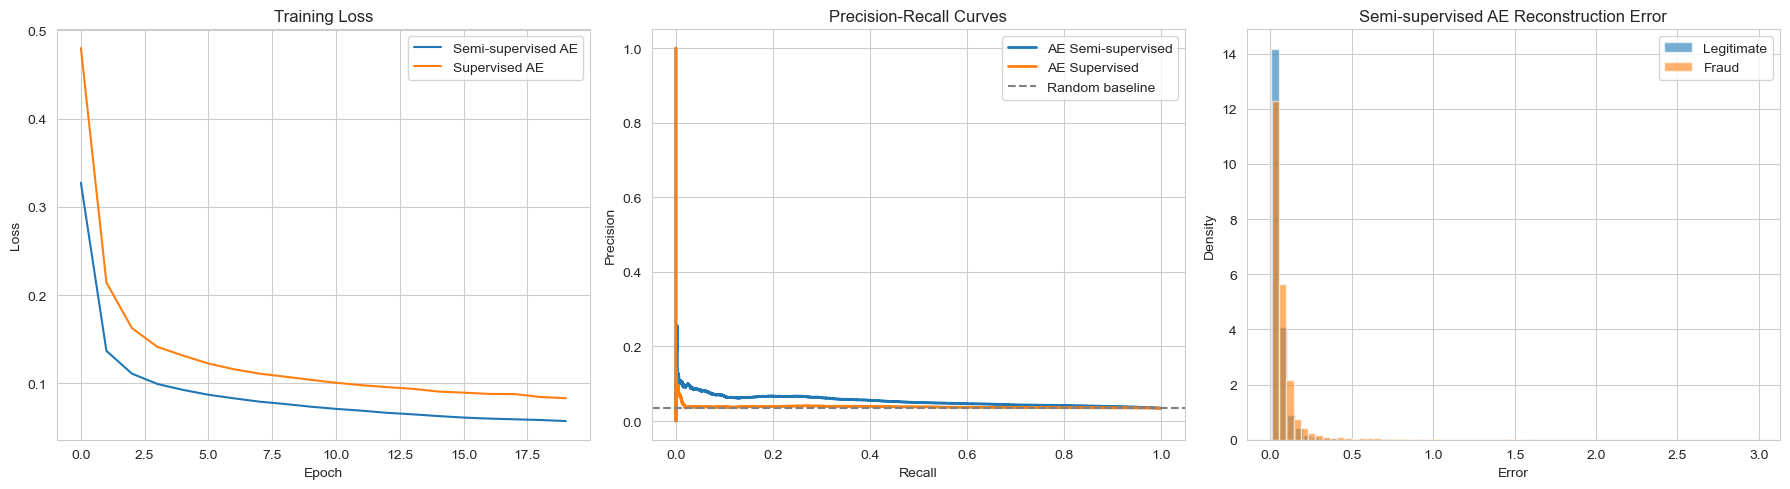

In [5]:
# VISUAL COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
axes[0].plot(semi_history, label='Semi-supervised AE')
axes[0].plot(sup_history, label='Supervised AE')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# PR curves
for curve, label in [(semi_curve, 'AE Semi-supervised'), (sup_curve, 'AE Supervised')]:
    precision, recall, _, _ = curve
    axes[1].plot(recall, precision, linewidth=2, label=label)
axes[1].axhline(y=y_test.mean(), linestyle='--', color='gray', label='Random baseline')
axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

# Error distribution
axes[2].hist(semi_scores_test[y_test == 0], bins=60, alpha=0.6, label='Legitimate', density=True)
axes[2].hist(semi_scores_test[y_test == 1], bins=60, alpha=0.6, label='Fraud', density=True)
axes[2].set_title('Semi-supervised AE Reconstruction Error')
axes[2].set_xlabel('Error')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.show()


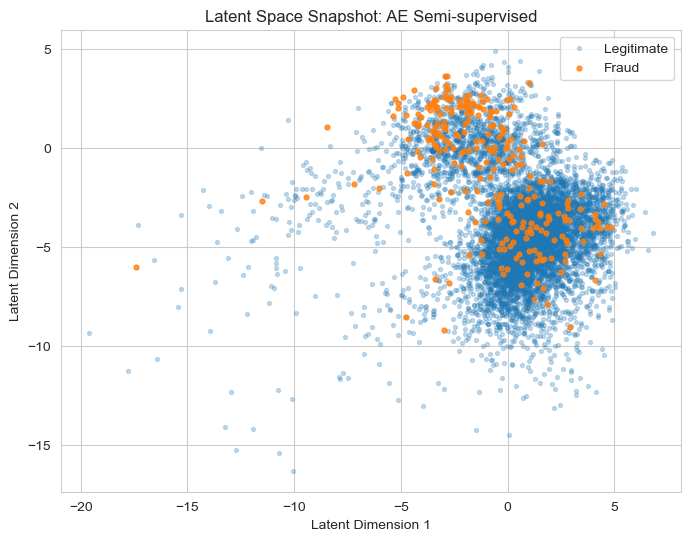

In [6]:
# LATENT SPACE QUICK VIEW
# Plot first two latent dimensions from the better AE variant.
best_latent = semi_latent_test if semi_metrics['AUPRC'] >= sup_metrics['AUPRC'] else sup_latent_test
best_name = 'AE Semi-supervised' if semi_metrics['AUPRC'] >= sup_metrics['AUPRC'] else 'AE Supervised'

sample_n = min(8000, len(best_latent))
idx = np.random.RandomState(42).choice(len(best_latent), size=sample_n, replace=False)
plot_latent = best_latent[idx]
plot_y = y_test[idx]

plt.figure(figsize=(8, 6))
plt.scatter(plot_latent[plot_y == 0, 0], plot_latent[plot_y == 0, 1], s=8, alpha=0.25, label='Legitimate')
plt.scatter(plot_latent[plot_y == 1, 0], plot_latent[plot_y == 1, 1], s=12, alpha=0.8, label='Fraud')
plt.title(f'Latent Space Snapshot: {best_name}')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.legend()
plt.show()


In [7]:
# SAVE OUTPUTS FOR NOTEBOOK 08
results_dir = ROOT / 'data/processed/dl_results'
results_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    'y_true': y_test,
    'ae_semi_score': semi_scores_test,
    'ae_supervised_score': sup_scores_test
}).to_csv(results_dir / 'autoencoder_scores_ieee.csv', index=False)

summary = pd.DataFrame([semi_metrics, sup_metrics])
summary.to_csv(results_dir / 'autoencoder_summary_ieee.csv', index=False)
summary


,model,AUPRC,ROC_AUC,best_f1_threshold,best_f1,precision_at_best_f1,recall_at_best_f1,confusion_matrix
0,AE_SemiSupervised,0.054210,0.620358,0.082805,0.106029,0.066604,0.259843,"[[99245, 14799], [3008, 1056]]"
1,AE_Supervised,0.038201,0.534016,0.052600,0.071851,0.039327,0.415354,"[[72810, 41234], [2376, 1688]]"


### Report notes

Interpret these results in Notebook 08 using three angles:
- **AUPRC / ROC AUC**: does AE materially improve on the classical benchmark?
- **Semi-supervised vs supervised**: which training regime fits tabular fraud data better?
- **Operational value**: if uplift is small, LightGBM may still be preferable due to speed and interpretability.
